In [105]:
import polars as pl
import numpy as np  
import os
import matplotlib.pyplot as plt

In [106]:
path = "../data/raw/"
files = os.listdir(path)
files

['Gold_1d.parquet',
 'Gold_1h.parquet',
 'Nifty50_1d.parquet',
 'Nifty50_1h.parquet',
 'USDINR_1d.parquet',
 'USDINR_1h.parquet']

In [107]:
gold = pl.read_parquet("../data/raw/Gold_1d.parquet")
nifty = pl.read_parquet("../data/raw/Nifty50_1d.parquet")
usdinr = pl.read_parquet("../data/raw/USDINR_1d.parquet")

In [108]:
nifty.head()

"('Close', '^NSEI')","('High', '^NSEI')","('Low', '^NSEI')","('Open', '^NSEI')","('Volume', '^NSEI')",Date
f64,f64,f64,f64,i64,datetime[ns]
6221.149902,6358.299805,6211.299805,6301.25,158100,2014-01-02 00:00:00
6211.149902,6221.700195,6171.25,6194.549805,139000,2014-01-03 00:00:00
6191.450195,6224.700195,6170.25,6220.850098,118300,2014-01-06 00:00:00
6162.25,6221.5,6144.75,6203.899902,138600,2014-01-07 00:00:00
6174.600098,6192.100098,6160.350098,6178.049805,146900,2014-01-08 00:00:00


In [109]:
df_close = (
    nifty
    .select(["Date", "('Close', '^NSEI')"])
    .rename({"('Close', '^NSEI')":"Nifty"})
    .join(
        gold
        .select(["Date","('Close', 'GOLDBEES.NS')"])
        .rename({"('Close', 'GOLDBEES.NS')":"Gold"}),
        on="Date"
    )
    .join(
        usdinr
        .select(["Date","('Close', 'USDINR=X')"])
        .rename({"('Close', 'USDINR=X')":"USDINR"}),
        on="Date"
    )
)
df_close.head()

Date,Nifty,Gold,USDINR
datetime[ns],f64,f64,f64
2014-01-02 00:00:00,6221.149902,27.460501,61.84
2014-01-03 00:00:00,6211.149902,27.653,62.060001
2014-01-06 00:00:00,6191.450195,27.627001,62.23
2014-01-07 00:00:00,6162.25,27.6115,62.310001
2014-01-08 00:00:00,6174.600098,27.400499,62.080002


In [110]:
df_close.tail()

Date,Nifty,Gold,USDINR
datetime[ns],f64,f64,f64
2025-12-24 00:00:00,26142.099609,113.209999,89.507896
2025-12-26 00:00:00,26042.300781,114.309998,90.105904
2025-12-29 00:00:00,25942.099609,113.029999,89.8293
2025-12-30 00:00:00,25938.849609,111.169998,89.900002
2025-12-31 00:00:00,26129.599609,110.110001,89.769402


In [111]:
df_close = df_close.drop_nulls()


In [112]:
df_norm = df_close.select([
    pl.col("Date"),
    (pl.col("Nifty") / pl.col("Nifty").first()).alias("Nifty_norm"),
    (pl.col("Gold") / pl.col("Gold").first()).alias("Gold_norm"),
    (pl.col("USDINR") / pl.col("USDINR").first()).alias("USDINR_norm")
])

In [113]:
df_norm.head()

Date,Nifty_norm,Gold_norm,USDINR_norm
datetime[ns],f64,f64,f64
2014-01-02 00:00:00,1.0,1.0,1.0
2014-01-03 00:00:00,0.998393,1.00701,1.003558
2014-01-06 00:00:00,0.995226,1.006063,1.006307
2014-01-07 00:00:00,0.990532,1.005499,1.0076
2014-01-08 00:00:00,0.992517,0.997815,1.003881


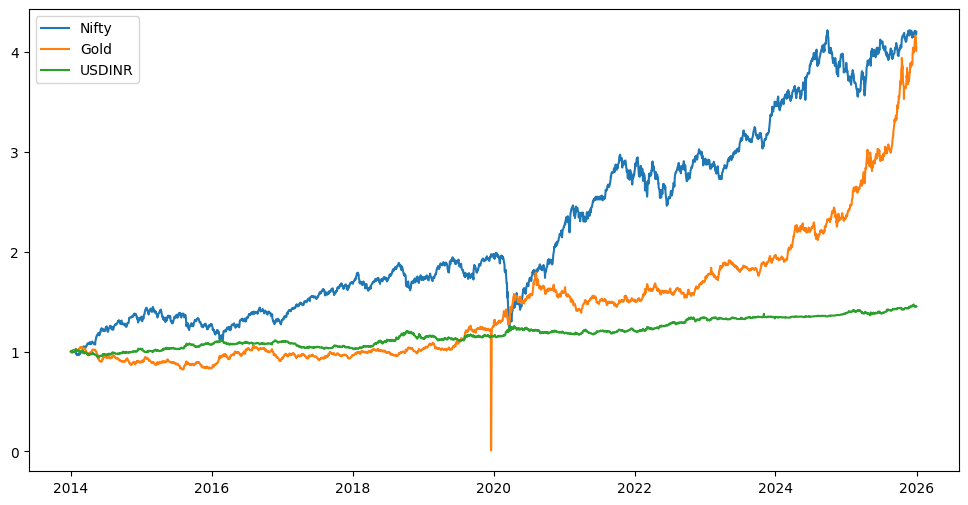

In [114]:
plt.figure(figsize=(12,6))
plt.plot(df_norm['Date'],df_norm['Nifty_norm'],label='Nifty')
plt.plot(df_norm['Date'],df_norm['Gold_norm'],label='Gold')
plt.plot(df_norm['Date'],df_norm['USDINR_norm'],label='USDINR')
plt.legend()
plt.show()

In [115]:
low_gold = (
    df_close
    .select(["Date","Gold"])
    .sort("Gold")
    .head()
)
low_gold


Date,Gold
datetime[ns],f64
2019-12-19 00:00:00,0.3355
2019-12-20 00:00:00,0.3365
2015-08-06 00:00:00,22.4855
2015-08-05 00:00:00,22.511999
2015-08-07 00:00:00,22.6105


In [125]:
bad_dates = [
    pl.datetime(2019, 12, 19),
    pl.datetime(2019, 12, 20),
]
for date in bad_dates:
    df_close = df_close.filter(pl.col("Date") != date)


In [126]:
df_norm = df_close.select([
    pl.col("Date"),
    (pl.col("Nifty") / pl.col("Nifty").first()).alias("Nifty_norm"),
    (pl.col("Gold") / pl.col("Gold").first()).alias("Gold_norm"),
    (pl.col("USDINR") / pl.col("USDINR").first()).alias("USDINR_norm")
])

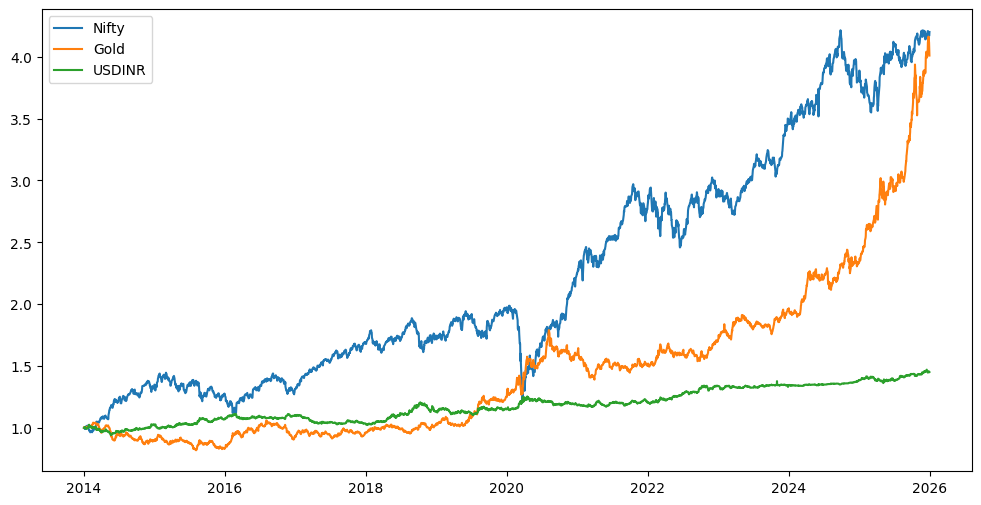

In [127]:
plt.figure(figsize=(12,6))
plt.plot(df_norm['Date'],df_norm['Nifty_norm'],label='Nifty')
plt.plot(df_norm['Date'],df_norm['Gold_norm'],label='Gold')
plt.plot(df_norm['Date'],df_norm['USDINR_norm'],label='USDINR')
plt.legend()
plt.show()

In [148]:
df_ret = df_close.select([
    pl.col("Date"),
    pl.col("Nifty").pct_change().alias("Nifty_Ret"),
    pl.col("Gold").pct_change().alias("Gold_Ret"),
    pl.col("USDINR").pct_change().alias("USDINR_Ret")
]).drop_nulls()

In [149]:
nifty_ret = df_ret["Nifty_Ret"].to_numpy()
gold_ret  = df_ret["Gold_Ret"].to_numpy()
usdinr_ret = df_ret['USDINR_Ret'].to_numpy()
mu_n, sigma_n = nifty_ret.mean(), nifty_ret.std()
mu_g, sigma_g = gold_ret.mean(), gold_ret.std()
mu_u, sigma_u = usdinr_ret.mean(), usdinr_ret.std()

xmin = min(nifty_ret.min(), gold_ret.min(),usdinr_ret.min())
xmax = max(nifty_ret.max(), gold_ret.max(),usdinr_ret.max())

x = np.linspace(xmin, xmax, 500)



In [156]:
from scipy.stats import norm,skew,kurtosis

pdf_n = norm.pdf(x, mu_n, sigma_n)
pdf_g = norm.pdf(x, mu_g, sigma_g)
pdf_u = norm.pdf(x, mu_u, sigma_u)

skew_n = skew(nifty_ret)
skew_g = skew(gold_ret)
skew_u = skew(usdinr_ret)
kurt_n = kurtosis(nifty_ret,fisher=True)
kurt_g = kurtosis(gold_ret,fisher=True)
kurt_u = kurtosis(usdinr_ret,fisher=True)

print("Skewness of Nifty Returns:", skew_n)
print("Skewness of Gold Returns:", skew_g)
print("Skewness of USDINR Returns:", skew_u)
print("Kurtosis of Nifty Returns:", kurt_n)
print("Kurtosis of Gold Returns:", kurt_g)
print("Kurtosis of USDINR Returns:", kurt_u)


Skewness of Nifty Returns: -1.0176188029437727
Skewness of Gold Returns: 0.261844709643969
Skewness of USDINR Returns: 0.2204043020636127
Kurtosis of Nifty Returns: 17.33788264121488
Kurtosis of Gold Returns: 3.569949820740482
Kurtosis of USDINR Returns: 4.218323329138066


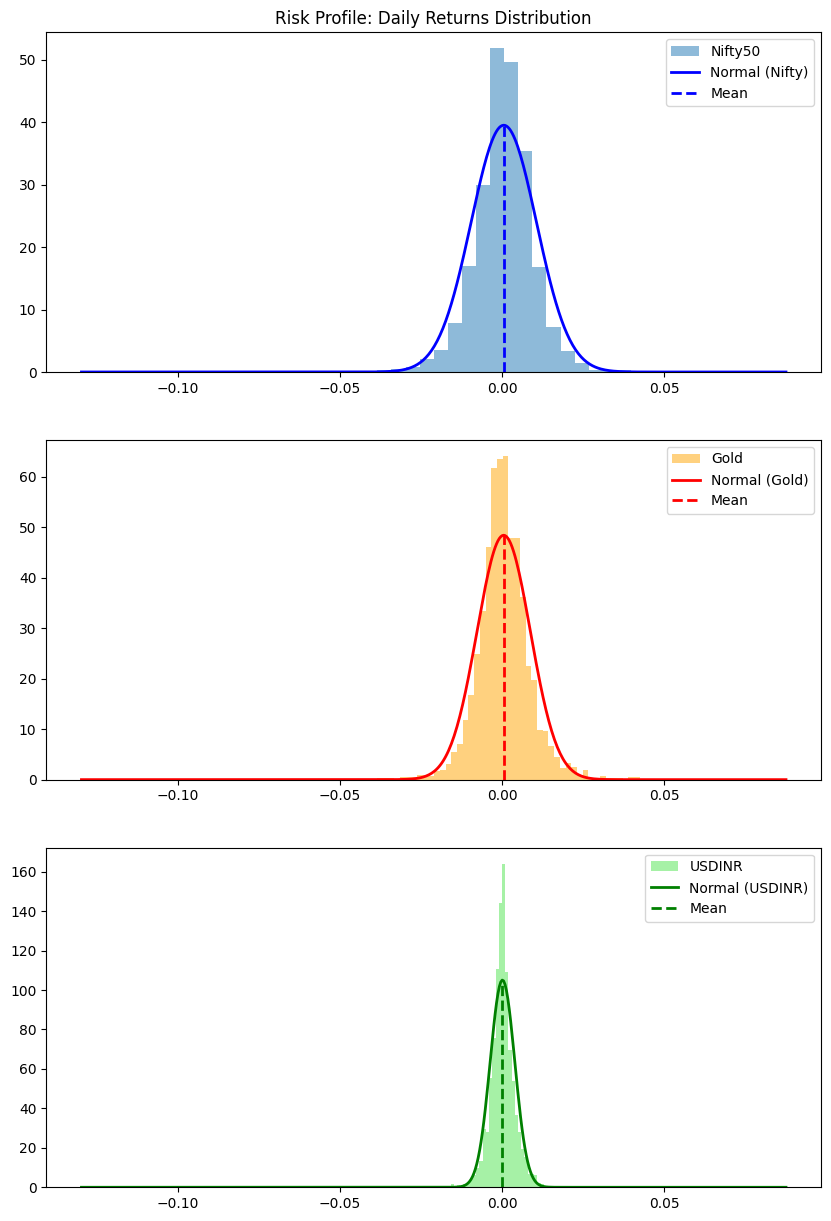

In [171]:
fig,axes = plt.subplots(3,1,figsize=(10, 15))


axes[0].hist(df_ret["Nifty_Ret"], bins=50, alpha=0.5, label="Nifty50", density=True)
axes[1].hist(df_ret["Gold_Ret"], bins=50, alpha=0.5, label="Gold", density=True,color="orange")
axes[2].hist(df_ret['USDINR_Ret'], bins=50, alpha=0.8, label="USDINR", density=True,color="lightgreen")
axes[0].plot(x, pdf_n, color="blue", linewidth=2, label="Normal (Nifty)")
axes[1].plot(x, pdf_g, color="red", linewidth=2, label="Normal (Gold)")
axes[2].plot(x, pdf_u, color="green", linewidth=2, label="Normal (USDINR)")
axes[0].plot([mu_n,mu_n],[0,pdf_n.max()], color="blue", linestyle="--", linewidth=2, label="Mean")
axes[1].plot([mu_g,mu_g],[0,pdf_g.max()], color="red", linestyle="--", linewidth=2, label="Mean")
axes[2].plot([mu_u,mu_u],[0,pdf_u.max()], color="green", linestyle="--", linewidth=2, label="Mean")
axes[0].set_title("Risk Profile: Daily Returns Distribution")
axes[0].legend()    
axes[1].legend()    
axes[2].legend()    
plt.show()